# Results Analysis — HetMap Architecture Recovery

Organized around the three research questions in the paper.  
All scores reported as **percentages (×100)**, matching Table 1–4 in the paper.  
Data loaded from `all_results.csv` files produced by `collect_results.py`.

| Section | RQ | What it does |
|---|---|---|
| 1 | — | USER CONFIG |
| 2 | — | Setup & load |
| 3 | RQ1 | HGT-W2V vs MLP / GCN / GAT |
| 4 | RQ2 | Structural ablation (F / FF / FM / FFM with W2V fixed) |
| 5 | RQ3a | Fine-tuning check: MLP-ZS vs MLP-FT |
| 6 | RQ3 | W2V vs UniXcoder at MLP / F / FM level |
| 7 | — | Precision–Recall analysis (all views) |

cd results

python collect_results.py

## 1. USER CONFIG

In [1]:
import numpy as np
from matplotlib.ticker import MaxNLocator
import pandas as pd
from pathlib import Path
from scipy.stats import ranksums
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

warnings.filterwarnings("ignore")
plt.rcParams["text.usetex"] = True
sns.set_theme(
    style="ticks",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": True,
        "axes.spines.bottom": True,
        "axes.edgecolor": "black",
        "axes.linewidth": 1,
        "xtick.bottom": True,
        "ytick.left": True,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.major.width": 1,
        "ytick.major.width": 1,
        "axes.grid": True,
        "axes.grid.axis": "x",
        "grid.alpha": 0.7,
        "grid.linestyle": "-",
        "grid.linewidth": 0.7,
    }
)
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "xtick.major.size":4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.axisbelow": True,
    "grid.alpha": 0.4,
    "grid.linestyle": "-",
    "grid.linewidth": 0.5,
})
ALPHA = 0.05

In [2]:
RESULTS_BASE  = Path("results")   # relative to the HetMap repo root
W2V_DIR       = RESULTS_BASE / "HGT_W2V"
UXC_DIR       = RESULTS_BASE / "HGT_UXC"
N2V_DIR      = RESULTS_BASE / "HGT_N2V"

# Datasets to include (None = all 11)
DATASETS = None  # e.g. ['Ant', 'SH-3D', 'Jabref']


"""
Shortened method-name / label scheme for matplotlib plots.

Labels use matplotlib mathtext subscript syntax (e.g. "UXC$_{FT}$", "W2V$_{FFM}$"),
mirroring the paper's LaTeX macros (\\zs{}, \\ft{}, \\f{}, \\fm{}, \\ff{}, \\ffm{})
without relying on LaTeX macro expansion, which matplotlib does not perform.

  UXC$_{ZS}$      <-> \\zs{}     (UniXcoder, zero-shot)
  UXC$_{FT}$      <-> \\ft{}     (UniXcoder, dependency-guided fine-tuned)
  X$_{F}$         <-> \\f{X}     (file-only graph)
  X$_{FM}$        <-> \\fm{X}    (file-member graph)
  X$_{FF}$        <-> \\ff{X}    (folder-file graph)
  X$_{FFM}$       <-> \\ffm{X}   (folder-file-member, full graph)

Plain feature labels (no graph shape): N2V, W2V, UXC$_{ZS}$, UXC$_{FT}$ -- these ARE the MLP/no-graph baselines.
Graph-shape labels apply once HGT is established (post-RQ1), so an 'HGT-' prefix is dropped:
  a bare feature name with a $_{F}$/$_{FM}$/$_{FF}$/$_{FFM}$ suffix already implies "HGT initialized with this feature."
RQ1 backbones (GCN, GAT, MLP, HGT) keep their own short names since architecture IS the variable there.

NOTE: this file only defines RQ*_METHODS and METHOD_PALETTE. It assumes RESULTS_BASE,
W2V_DIR, UXC_DIR, N2V_DIR (pathlib.Path objects) are already defined earlier in your
script -- paste this block into your existing config in place of the old RQ*_METHODS /
METHOD_PALETTE definitions; do not run this file standalone.
"""

# ── RQ1: architecture is the variable; feature fixed at W2V+folder ──
RQ1_METHODS = [
    (W2V_DIR, 'MLP_FT',  'MLP'),
    (W2V_DIR, 'GAT',     'GAT'),
    (W2V_DIR, 'FT_FFM', 'HGT'),
    # (W2V_DIR, 'FT_FFM1', 'HGT1'),
]

# ── RQ2: no graph, feature is the variable ──
RQ2_METHODS = [
    (N2V_DIR, 'MLP',          'N2V'),
    (W2V_DIR, 'MLP',          'W2V'),
    (UXC_DIR, 'MLP_file_zs',  'UXC$_{ZS}$'),
    (UXC_DIR, 'MLP_file_ft',  'UXC$_{FT}$'),
]

# ── RQ3: feature x graph-shape grid; HGT is implied, dropped from the name ──
RQ3_METHODS = [
    (W2V_DIR, 'MLP',        'W2V'),
    (W2V_DIR, 'File_only',  'W2V$_{F}$'),
    (W2V_DIR, 'FM',         'W2V$_{FM}$'),
    (W2V_DIR, 'FF',         'W2V$_{FF}$'),
    (W2V_DIR, 'FFM',        'W2V$_{FFM}$'),

    (UXC_DIR, 'MLP_file_ft', 'UXC$_{FT}$'),
    (UXC_DIR, 'File_only',   'UXC$_{F}$'),
    (UXC_DIR, 'FM',          'UXC$_{FM}$'),
    (UXC_DIR, 'FF',          'UXC$_{FF}$'),
    (UXC_DIR, 'FFM',         'UXC$_{FFM}$'),

    (N2V_DIR, 'MLP',        'N2V'),
    (N2V_DIR, 'File_only',  'N2V$_{F}$'),
    (N2V_DIR, 'FM',         'N2V$_{FM}$'),
    (N2V_DIR, 'FF',         'N2V$_{FF}$'),
    (N2V_DIR, 'FFM',        'N2V$_{FFM}$'),
]
# ── palette: one hue per feature family, shade darkens with graph size ──
# Keyed on the macro-formatted label strings used above, since those are what
# the plotting code will look up directly (no separate internal short-name needed).
METHOD_PALETTE = {
    # RQ1 backbones
    'HGT': '#A6CEE3',
    'GAT': '#B2DF8A',
    'MLP': '#CAB2D6',

    # RQ2 bare features (no graph)
    'N2V': '#B2DF8A', 
    'W2V': '#A6CEE3', 
    'UXC$_{ZS}$': '#FB9A99', 
    'UXC$_{FT}$': '#CAB2D6',
    
    # RQ3 W2V family — all darker than RQ2 W2V (#A6CEE3)
    'W2V$_{F}$':   '#8BC1DE',
    'W2V$_{FM}$':  '#68ADD1',
    'W2V$_{FF}$':  '#438FB9',
    'W2V$_{FFM}$': '#216FA5',


    # RQ3 N2V family — all darker than RQ2 N2V (#B2DF8A)
    'N2V$_{F}$':   '#94CC70',
    'N2V$_{FM}$':  '#72B850',
    'N2V$_{FF}$':  '#519B34',
    'N2V$_{FFM}$': '#34751E',


    # RQ3 UXC-FT family — all darker than RQ2 UXC-FT (#CAB2D6)
    'UXC$_{F}$':   '#B898CA',
    'UXC$_{FM}$':  '#9B73B4',
    'UXC$_{FF}$':  '#7B5595',
    'UXC$_{FFM}$': '#5C3974',
    }

RQ1_METHOD_ORDER = ['HGT', 'GAT', 'MLP',]
RQ2_METHOD_ORDER = ['N2V', 'W2V', 'UXC$_{ZS}$', 'UXC$_{FT}$']
RQ3_METHOD_ORDER = ['W2V', 'UXC$_{FT}$', 'UXC$_{F}$', 'UXC$_{FM}$', 'UXC$_{FF}$', 'UXC$_{FFM}$', 'N2V', 'N2V$_{F}$', 'N2V$_{FM}$', 'N2V$_{FF}$', 'N2V$_{FFM}$']

## 2. Setup & load

In [4]:
_cache: dict = {}
SCORE_COLS = ['f1_macro','f1_micro']
# ── canonical dataset order (used everywhere datasets are listed/printed/plotted) ──
DATASET_ORDER = ['A.UML', 'C.Img', 'JabRef', 'Lucene', 'SH-3D', 'T.Mates',
                  'Bash', 'HDF', 'Chrome', 'HDC']

def _ordered_datasets(ds_iterable):
    """
    Return datasets from `ds_iterable` sorted according to DATASET_ORDER.
    Any dataset not in DATASET_ORDER is appended (alphabetically) at the end
    instead of being dropped, so nothing silently disappears.
    """
    ds_set = set(ds_iterable)
    ordered = [d for d in DATASET_ORDER if d in ds_set]
    leftover = sorted(ds_set - set(DATASET_ORDER))
    return ordered + leftover


def _load_root(root_dir: Path) -> pd.DataFrame:
    if root_dir not in _cache:
        p = root_dir / 'all_results.csv'
        if not p.exists():
            raise FileNotFoundError(f"{p} — run collect_results.py first.")
        df = pd.read_csv(p)
        # normalise to 0-1 if stored as 0-100
        for col in SCORE_COLS:
            if col in df.columns and df[col].median() > 1:
                df[col] /= 100.0
        _cache[root_dir] = df
    return _cache[root_dir]

def get(root_dir: Path, method_name: str, label: str) -> pd.DataFrame:
    df = _load_root(root_dir)
    df = df[df['method'] == method_name].copy()
    if df.empty:
        avail = _load_root(root_dir)['method'].unique().tolist()
        raise ValueError(f"'{method_name}' not found. Available: {avail}")
    if DATASETS:
        df['dataset'] = df['dataset'].replace('Jabref', 'JabRef')
        df = df[df['dataset'].isin(DATASETS)]
    df['_label'] = label
    return df

def load_group(method_list: list) -> dict:
    """Load a list of (root, name, label) into {label: DataFrame}."""
    data = {}
    for root_dir, method_name, label in method_list:
        try:
            data[label] = get(root_dir, method_name, label)
        except (FileNotFoundError, ValueError) as e:
            print(f"  SKIP {label}: {e}")
    return data

# ── statistical helpers ───────────────────────────────────────────────────────
def cliff_delta(a, b) -> float:
    a, b = np.asarray(a), np.asarray(b)
    return (np.sum(a[:,None]>b[None,:]) - np.sum(a[:,None]<b[None,:])) / (len(a)*len(b))

def interpret_cliff(d: float) -> str:
    ad = abs(d)
    if ad < 0.147: return 'negligible'
    if ad < 0.330: return 'small'
    if ad < 0.474: return 'medium'
    return 'large'

def mw_test(a, b):
    """Wilcoxon rank-sum test (scipy.stats.ranksums) + Cliff's Delta."""
    stat, p = ranksums(a, b)
    cd = cliff_delta(a, b)
    return stat, p, cd, interpret_cliff(cd)


def stat_table(data: dict, metrics: list):
    """
    Compute Wilcoxon rank-sum test + Cliff's Delta for EVERY pairwise
    combination of methods in `data`, for each metric in `metrics`,
    per-dataset (in DATASET_ORDER) and pooled.

    Returns a single tidy pandas DataFrame, one row per
    (metric, method_a, method_b, dataset):
        metric, comparison, method_a, method_b, dataset,
        method_a med%, method_b med%, median_diff, median_diff%,
        method_a IQR, method_b IQR, stat, p, p_holm, sig, sig_holm,
        Cliff's d, effect

    Holm correction is applied within each metric, across all
    comparisons (all pairs x all datasets x pooled) for that metric.
    """

    labels = list(data.keys())
    all_pairs = list(combinations(labels, 2))

    all_rows = []

    for metric in metrics:

        metric_rows = []

        for la, lb in all_pairs:

            df_a, df_b = data[la], data[lb]
            desc = f'{la} vs {lb}'

            # -----------------------------------------------------
            # Per-dataset comparison (canonical order)
            # -----------------------------------------------------
            for ds in _ordered_datasets(set(df_a['dataset']) & set(df_b['dataset'])):

                a = df_a.loc[df_a['dataset'] == ds, metric].dropna().values
                b = df_b.loc[df_b['dataset'] == ds, metric].dropna().values
                if len(a) < 2 or len(b) < 2:
                    continue

                stat, p, cd, interp = mw_test(a, b)

                med_a, med_b = np.median(a), np.median(b)
                median_diff = med_a - med_b
                q1_a, q3_a = np.percentile(a, [25, 75])
                q1_b, q3_b = np.percentile(b, [25, 75])

                row = {
                    'metric': metric,
                    'comparison': desc,
                    'method_a': la,
                    'method_b': lb,
                    'dataset': ds,
                    'method_a med%': round(med_a * 100, 1),
                    'method_b med%': round(med_b * 100, 1),
                    'median_diff': round(median_diff, 4),
                    'median_diff%': round(median_diff * 100, 1),
                    'method_a IQR': round(q3_a - q1_a, 4),
                    'method_b IQR': round(q3_b - q1_b, 4),
                    'stat': round(stat, 3),
                    'p': p,
                    'p_holm': None,
                    'sig': '',
                    'sig_holm': '',
                    "Cliff's d": round(cd, 3),
                    'effect': interp,
                    '_p_raw': p,
                }
                metric_rows.append(row)

            # -----------------------------------------------------
            # Pooled comparison
            # -----------------------------------------------------
            a_all = df_a[metric].dropna().values
            b_all = df_b[metric].dropna().values

            if len(a_all) >= 2 and len(b_all) >= 2:

                stat, p, cd, interp = mw_test(a_all, b_all)

                med_a, med_b = np.median(a_all), np.median(b_all)
                median_diff = med_a - med_b
                q1_a, q3_a = np.percentile(a_all, [25, 75])
                q1_b, q3_b = np.percentile(b_all, [25, 75])

                row = {
                    'metric': metric,
                    'comparison': desc,
                    'method_a': la,
                    'method_b': lb,
                    'dataset': 'ALL (pooled)',
                    'method_a med%': round(med_a * 100, 1),
                    'method_b med%': round(med_b * 100, 1),
                    'median_diff': round(median_diff, 4),
                    'median_diff%': round(median_diff * 100, 1),
                    'method_a IQR': round(q3_a - q1_a, 4),
                    'method_b IQR': round(q3_b - q1_b, 4),
                    'stat': round(stat, 3),
                    'p': p,
                    'p_holm': None,
                    'sig': '',
                    'sig_holm': '',
                    "Cliff's d": round(cd, 3),
                    'effect': interp,
                    '_p_raw': p,
                }
                metric_rows.append(row)

        # =========================================================
        # Holm correction within this metric, across all comparisons
        # (all pairs x all datasets x pooled)
        # =========================================================
        m = len(metric_rows)
        if m > 0:
            sorted_rows = sorted(metric_rows, key=lambda r: r['_p_raw'])
            previous_adjusted = 0.0
            for rank, row in enumerate(sorted_rows):
                raw_p = row['_p_raw']
                adjusted_p = max((m - rank) * raw_p, previous_adjusted)
                adjusted_p = min(adjusted_p, 1.0)
                row['p_holm'] = adjusted_p
                row['sig'] = '*' if raw_p < ALPHA else ''
                row['sig_holm'] = '*' if adjusted_p < ALPHA else ''
                previous_adjusted = adjusted_p

        for row in metric_rows:
            row['p'] = f"{row['p']:.4f}"
            row['p_holm'] = f"{row['p_holm']:.4f}" if row['p_holm'] is not None else None
            row.pop('_p_raw', None)

        all_rows.extend(metric_rows)

    result_df = pd.DataFrame(all_rows)

    cols = ['metric', 'comparison', 'method_a', 'method_b', 'dataset',
            'method_a med%', 'method_b med%', 'median_diff', 'median_diff%',
            'method_a IQR', 'method_b IQR', 'stat', 'p', 'p_holm',
            'sig', 'sig_holm', "Cliff's d", 'effect']
    return result_df[cols]

def summary_table(data: dict, metrics=None):
    """Median scores ×100, bold best per column."""
    if metrics is None:
        metrics = ['f1_micro','f1_macro','precision_macro','recall_macro']
    rows = []
    for label, df in data.items():
        row = {'method': label}
        for c in metrics:
            if c in df.columns:
                row[c+'(%)'] = round(df[c].median()*100, 1)
        rows.append(row)
    tbl = pd.DataFrame(rows).set_index('method')
    def bold_max(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
    return tbl.style.apply(bold_max)

def summary_table_(data: dict, metric: str = 'f1_micro'):
    """
    Median score ×100 per method, per dataset, columns in DATASET_ORDER.
    Bonus helper matching the requested table order — safe to ignore/remove
    if you don't need it.
    """
    all_ds = _ordered_datasets(ds for df in data.values() for ds in df['dataset'].unique())
    rows = []
    for label, df in data.items():
        row = {'method': label}
        for ds in all_ds:
            v = df.loc[df['dataset'] == ds, metric].dropna().values
            row[ds] = round(np.median(v) * 100, 1) if len(v) else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index('method')[all_ds]

In [5]:

TAB10 = plt.get_cmap('tab10').colors
def method_colors(labels):
    return {l: METHOD_PALETTE.get(l, TAB10[i % 10]) for i, l in enumerate(labels)}

def boxplot_group(data: dict, metric: list, title: str, save_path=None):
    """
    Boxplot for a group (seaborn). Scores multiplied by 100 for display.

    `metric` is a list of metric names; one subplot is drawn per metric,
    arranged as:
      1 metric  -> 1x1
      2 metrics -> 1x2
      3 metrics -> 1x3
      4 metrics -> 2x2
      >4        -> grid with up to 3 columns
    """
    metrics = list(metric)
    n = len(metrics)

    if n <= 1:
        nrows, ncols = 1, 1
    elif n == 2:
        nrows, ncols = 2, 1
    elif n == 3:
        nrows, ncols = 1, 3
    elif n == 4:
        nrows, ncols = 2, 2
    else:
        ncols = 3
        nrows = int(np.ceil(n / ncols))

    labels = list(data.keys())
    colors = method_colors(labels)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(max(3, len(labels)) * ncols, 2.5 * nrows),
        squeeze=False, sharex=True, sharey=False
    )
    axes = axes.flatten()

    for ax_i, m in enumerate(metrics):
        ax = axes[ax_i]

        long_df = pd.concat([
            pd.DataFrame({'label': l, 'value': data[l][m].dropna().values * 100})
            for l in labels
        ], ignore_index=True)

        sns.boxplot(
            data=long_df, x='label', y='value', hue='label',
            order=labels, hue_order=labels,
            palette=colors, ax=ax,
            linewidth=0.8, medianprops=dict(color='black', linewidth=0.7),
            legend=False
        )
        for patch in ax.patches:
            patch.set_alpha(0.95)

        ax.set_xlabel('')
        ax.set_ylabel(' ')
        ax.set_title(m.replace('_', ' ').capitalize() if n > 1 else title)
        ax.tick_params(axis='x', rotation=0)

        for i, l in enumerate(labels):
            v = long_df.loc[long_df['label'] == l, 'value'].values
            ax.text(i, np.median(v) + 0.5, f' {np.median(v):.1f}', va='bottom', fontsize=8)

    for ax_i in range(n, len(axes)):
        axes[ax_i].set_visible(False)

    if n > 1:
        fig.suptitle(title)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def boxplot_(data: dict, metric: str, title: str,size=(10,5), nrows=2, ncols=5, save_path=None):
    """
    Grid of per-dataset boxplots (seaborn), horizontal (methods on y-axis).
    Scores ×100. Fixed 2 rows, columns computed. Y-axis (methods) ticks
    shared across all panels; x-axis (score) not shared across panels.

    Datasets are laid out in DATASET_ORDER (via _ordered_datasets),
    column-major, not alphabetically.
    """
    all_ds = _ordered_datasets(ds for df in data.values() for ds in df['dataset'].unique())
    if DATASETS:
        all_ds = [d for d in all_ds if d in DATASETS]
    labels = list(data.keys())
    colors = method_colors(labels)

    nrows = nrows
    ncols = ncols

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=size,
        sharey=True, sharex=False,
        squeeze=False
    )
    # fill column-major so datasets go down each column first, then across
    axes = axes.flatten(order='F')

    for ax_i, ds in enumerate(all_ds):
        ax = axes[ax_i]

        ds_labels = [l for l in labels if len(data[l].loc[data[l]['dataset'] == ds, metric].dropna())]
        if not ds_labels:
            ax.set_visible(False)
            continue

        long_df = pd.concat([
            pd.DataFrame({
                'label': l,
                'value': data[l].loc[data[l]['dataset'] == ds, metric].dropna().values * 100
            })
            for l in ds_labels
        ], ignore_index=True)

        sns.boxplot(
            data=long_df, y='label', x='value', hue='label',
            order=ds_labels, hue_order=ds_labels,
            palette=colors, ax=ax,
            linewidth=0.9, medianprops=dict(color='black', linewidth=0.6),
            legend=False, showfliers=False
        )
        for patch in ax.patches:
            patch.set_alpha(0.95)

        ax.set_title(ds, fontsize=12)
        ax.set_ylabel('')
        ax.tick_params(axis='y', labelsize=10)
        ax.set_xlabel('%', fontsize=10)
        ax.tick_params(axis='x', labelsize=10)

    for ax_i in range(len(all_ds), len(axes)):
        axes[ax_i].set_visible(False)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def boxplot_metrics_by_language(data, metrics, size=(5, 9), save_path=None):

    JAVA_DATASETS = ['A.UML', 'C.Img', 'JabRef', 'Lucene', 'SH-3D', 'T.Mates']
    CPP_DATASETS = ['Bash', 'HDF', 'Chrome', 'HDC']

    available = set(
        ds for df in data.values()
        for ds in df['dataset'].dropna().unique()
    )

    java_ds = [ds for ds in JAVA_DATASETS if ds in available]
    cpp_ds = [ds for ds in CPP_DATASETS if ds in available]

    if DATASETS:
        java_ds = [ds for ds in java_ds if ds in DATASETS]
        cpp_ds = [ds for ds in cpp_ds if ds in DATASETS]

    labels = [m for m in RQ1_METHOD_ORDER if m in data]
    labels += [m for m in data if m not in labels]
    colors = method_colors(labels)

    fig, axes = plt.subplots(
        2, 1,
        figsize=size,
        gridspec_kw={
            'height_ratios': [len(java_ds), len(cpp_ds)],
            'hspace': 0.15
        }
    )

    legend_handles = None
    legend_labels = None

    for ax, datasets, group_name in [
        (axes[0], java_ds, 'Java'),
        (axes[1], cpp_ds, 'C/C++')
    ]:

        long_df = pd.concat([
            pd.DataFrame({
                'dataset': ds,
                'method': method,
                'value': (
                    data[method]
                    .loc[data[method]['dataset'] == ds, metrics[0]]
                    .dropna()
                    .values * 100
                )
            })
            for method in labels
            for ds in datasets
            if len(
                data[method]
                .loc[data[method]['dataset'] == ds, metrics[0]]
                .dropna()
            ) > 0
        ], ignore_index=True)

        sns.boxplot(
            data=long_df,
            y='dataset',
            x='value',
            hue='method',
            order=datasets,
            hue_order=labels,
            palette=colors,
            ax=ax,
            linewidth=0.9,
            width=0.7,
            showfliers=False,
            boxprops=dict(edgecolor='#555555'),
            medianprops=dict(color='black', linewidth=0.6)
        )

        # Automatic, independent x-axis range and ticks for each language.
        def group_whisker_bounds(g):
            q1, q3 = g.quantile([0.25, 0.75])
            iqr = q3 - q1
            lo_bound, hi_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            return g[(g >= lo_bound) & (g <= hi_bound)].agg(['min', 'max'])

        bounds = long_df.groupby(['dataset', 'method'])['value'].apply(group_whisker_bounds)
        whisker_lo = bounds.xs('min', level=-1).min()
        whisker_hi = bounds.xs('max', level=-1).max()

        pad = max(1.5, (whisker_hi - whisker_lo) * 0.08)
        lo, hi = whisker_lo - pad, whisker_hi + pad
        ax.set_xlim(lo, hi)

        target_ticks = 5
        raw_step = (hi - lo) / target_ticks
        # snap to a "nice" step: 1, 2, 5, 10, 20, 50...
        magnitude = 10 ** np.floor(np.log10(raw_step))
        for candidate in [1, 2, 5, 10]:
            step = candidate * magnitude
            if step >= raw_step:
                break
        start = step * np.ceil(lo / step)
        ticks = np.arange(start, hi + 1e-9, step)

        # step = 5 if (hi - lo) > 15 else 2

        ax.set_xticks(ticks)
        ax.set_xlabel('')
        ax.set_ylabel('')

        # Larger and closer language labels.
        ax.text(
            1.0, 0.5, group_name,
            transform=ax.transAxes,
            rotation=270,
            va='center',
            ha='left',
            fontsize=12,
            clip_on=False
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.get_legend().remove()

    fig.legend(
        legend_handles,
        legend_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, 1),
        ncol=len(labels),
        fontsize=11,
        frameon=False,
        columnspacing=1.5,
        handletextpad=0.5
    )

    fig.subplots_adjust(
        left=0.17,
        right=0.88,
        top=0.92,
        bottom=0.07
    )

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)

    plt.show()
# ── load all groups ───────────────────────────────────────────────────────────
print('Loading data groups...')
RQ1 = load_group(RQ1_METHODS)
RQ2 = load_group(RQ2_METHODS)
RQ3 = load_group(RQ3_METHODS)
print('Done.')

Loading data groups...
Done.


---
## 3. RQ1 — Heterogeneous Graph vs Baselines (MLP / GCN / GAT)

All methods use Word2Vec + folder-path features. HGT uses the full FFM graph.

In [123]:
print('=== RQ1 Summary Table (median %) ===')
summary_table(RQ1)

=== RQ1 Summary Table (median %) ===


,f1_micro(%),f1_macro(%),precision_macro(%),recall_macro(%)
method,,,,
MLP,91.300000,82.800000,94.400000,82.700000
GAT,93.200000,83.900000,92.500000,84.300000
HGT,97.500000,94.000000,97.000000,93.400000


In [124]:
# Per-dataset median micro-F1 (%)
parts = [RQ1[l].groupby('dataset')['f1_micro'].median().rename(l)*100 for l in RQ1]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
def bold_max(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
tbl.style.apply(bold_max, axis=1)

,MLP,GAT,HGT
dataset,,,
A.UML,89.600000,93.600000,98.300000
Bash,82.900000,87.400000,84.900000
C.Img,94.100000,95.500000,100.000000
Chrome,72.100000,89.300000,95.700000
HDC,87.800000,88.400000,85.800000
HDF,89.400000,83.700000,94.300000
JabRef,91.800000,95.800000,96.800000
Lucene,94.900000,94.900000,99.100000
SH-3D,95.600000,96.300000,100.000000


In [125]:
# Per-dataset median micro-F1 (%)
parts = [RQ1[l].groupby('dataset')['f1_macro'].median().rename(l)*100 for l in RQ1]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
def bold_max(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
tbl.style.apply(bold_max, axis=1)

,MLP,GAT,HGT
dataset,,,
A.UML,81.600000,83.200000,94.400000
Bash,62.900000,68.500000,66.600000
C.Img,90.800000,91.500000,100.000000
Chrome,59.500000,81.100000,85.600000
HDC,76.900000,74.400000,53.400000
HDF,89.400000,82.000000,94.200000
JabRef,65.900000,85.900000,82.300000
Lucene,85.600000,89.800000,99.000000
SH-3D,85.800000,85.000000,100.000000


In [126]:
# Per-dataset median micro-F1 (%)
parts = [RQ1[l].groupby('dataset')['f1_micro'].median().rename(l)*100 for l in RQ1]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
def bold_max(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
tbl.style.apply(bold_max, axis=1)

,MLP,GAT,HGT
dataset,,,
A.UML,89.600000,93.600000,98.300000
Bash,82.900000,87.400000,84.900000
C.Img,94.100000,95.500000,100.000000
Chrome,72.100000,89.300000,95.700000
HDC,87.800000,88.400000,85.800000
HDF,89.400000,83.700000,94.300000
JabRef,91.800000,95.800000,96.800000
Lucene,94.900000,94.900000,99.100000
SH-3D,95.600000,96.300000,100.000000


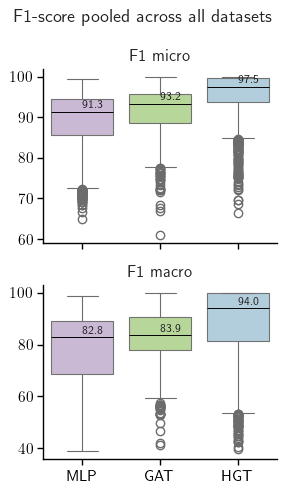

In [127]:
boxplot_group(RQ1, ['f1_micro','f1_macro'],
    'F1-score pooled across all datasets',
    RESULTS_BASE / 'Figures' / 'RQ1_boxplot_f1_pooled.pdf')

In [102]:
# boxplot_(RQ1, 'f1_micro',title='', size=(11,4),
#     save_path=RESULTS_BASE / 'Figures' / 'RQ1_boxplot_f1_micro.pdf')

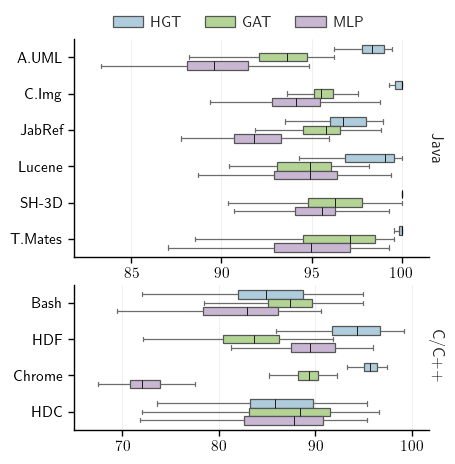

In [103]:
boxplot_metrics_by_language(RQ1, ['f1_micro'], size=(5,4.6),
    save_path=RESULTS_BASE / 'Figures' / 'RQ1_boxplot_f1_micro.pdf')

In [104]:
rq1_stats  = stat_table(RQ1,['f1_micro','f1_macro'])
rq1_stats.to_csv(RESULTS_BASE /'Statiscal_Test/rq1_stats.csv')  

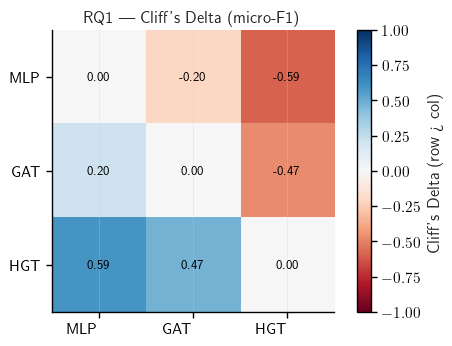

In [105]:
# Cliff's Delta heatmap — RQ1
labels = list(RQ1.keys())
n = len(labels)
mat = np.array([[cliff_delta(RQ1[la]['f1_micro'].dropna()*100,
                             RQ1[lb]['f1_micro'].dropna()*100)
                 for lb in labels] for la in labels])
fig, ax = plt.subplots(figsize=(n*1.4+1, n*1.2))
im = ax.imshow(mat, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label="Cliff's Delta (row > col)")
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(labels, ha='right')
ax.set_yticklabels(labels)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='white' if abs(mat[i,j])>0.6 else 'black')
ax.set_title("RQ1 — Cliff's Delta (micro-F1)")
plt.tight_layout()
plt.savefig(RESULTS_BASE / 'Figures' / 'RQ1_cliff_delta_heatmap.pdf', bbox_inches='tight')
plt.show()

---
## 4. RQ2 — Structural Ablation (W2V fixed, graph varies)

F = file-only dependency graph, FF = folder+file, FM = file+member, FFM = folder+file+member.

In [106]:
print('=== RQ2 Summary Table (median %) ===')
summary_table(RQ2)

=== RQ2 Summary Table (median %) ===


,f1_micro(%),f1_macro(%),precision_macro(%),recall_macro(%)
method,,,,
N2V,71.500000,41.600000,52.300000,43.200000
W2V,31.900000,4.000000,2.800000,9.500000
UXC$_{ZS}$,54.600000,31.500000,42.000000,32.200000
UXC$_{FT}$,65.000000,39.900000,49.400000,40.700000


In [107]:
print('=== RQ2 Summary Table (median %) ===')
summary_table(RQ2)

=== RQ2 Summary Table (median %) ===


,f1_micro(%),f1_macro(%),precision_macro(%),recall_macro(%)
method,,,,
N2V,71.500000,41.600000,52.300000,43.200000
W2V,31.900000,4.000000,2.800000,9.500000
UXC$_{ZS}$,54.600000,31.500000,42.000000,32.200000
UXC$_{FT}$,65.000000,39.900000,49.400000,40.700000


In [108]:
parts = [RQ2[l].groupby('dataset')['f1_micro'].median().rename(l)*100 for l in RQ2]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
tbl.style.apply(bold_max, axis=1)

,N2V,W2V,UXC$_{ZS}$,UXC$_{FT}$
dataset,,,,
A.UML,73.900000,32.000000,56.700000,64.200000
Bash,64.600000,32.000000,26.500000,28.200000
C.Img,82.500000,32.900000,49.700000,63.500000
Chrome,71.800000,47.800000,41.200000,51.900000
HDC,71.100000,26.200000,50.700000,66.100000
HDF,55.300000,20.500000,41.400000,48.800000
JabRef,80.000000,54.500000,77.100000,79.700000
Lucene,79.900000,25.600000,67.000000,75.500000
SH-3D,56.300000,27.100000,63.800000,66.500000


In [109]:
parts = [RQ2[l].groupby('dataset')['f1_macro'].median().rename(l)*100 for l in RQ2]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
tbl.style.apply(bold_max, axis=1)

,N2V,W2V,UXC$_{ZS}$,UXC$_{FT}$
dataset,,,,
A.UML,53.100000,3.700000,24.000000,35.000000
Bash,38.700000,3.500000,6.700000,4.300000
C.Img,74.100000,3.300000,26.700000,40.200000
Chrome,38.500000,8.700000,6.100000,10.000000
HDC,39.900000,3.800000,58.300000,69.100000
HDF,49.300000,3.900000,30.700000,40.300000
JabRef,37.800000,14.100000,33.800000,36.600000
Lucene,64.700000,5.900000,49.000000,59.400000
SH-3D,32.700000,4.800000,39.300000,41.700000


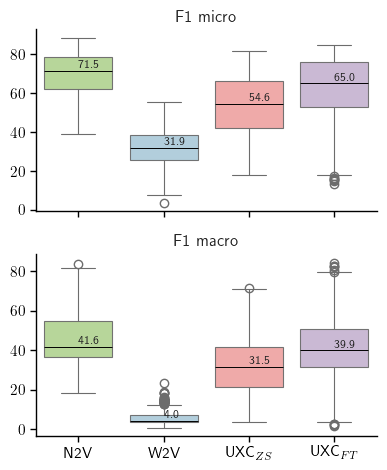

In [110]:
boxplot_group(RQ2, ['f1_micro','f1_macro'],
    '',
    RESULTS_BASE / 'Figures' / 'RQ2_boxplot_f1_pooled.pdf')

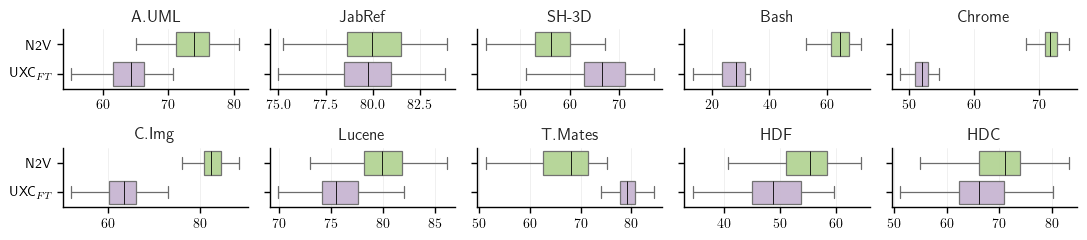

In [111]:
RQ2_subset = {k: RQ2[k] for k in  ['N2V','UXC$_{FT}$']}
boxplot_(RQ2_subset,  'f1_micro', title='', size=(11,2.7),
    save_path=RESULTS_BASE / 'Figures' / 'RQ2_boxplot_f1_micro.pdf')

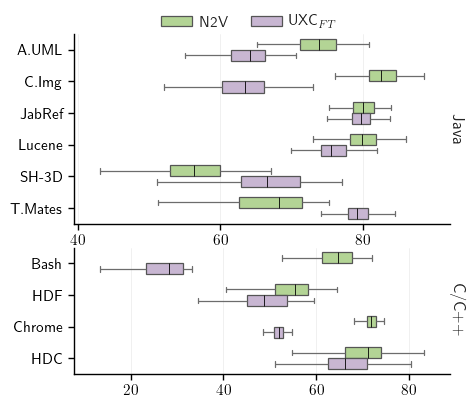

In [112]:
boxplot_metrics_by_language(RQ2_subset, ['f1_micro'], size=(5.3,4),
    save_path=RESULTS_BASE / 'Figures' / 'RQ2_boxplot_f1_microsubset.pdf')

In [113]:
rq2_stats  = stat_table(RQ2,['f1_micro','f1_macro'])
rq2_stats.to_csv(RESULTS_BASE /'Statiscal_Test/rq2_stats.csv') 

---
## 5. RQ3

Both methods: graph-free MLP. Only difference: frozen (zero-shot) vs dependency-guided fine-tuned UniXcoder embedding.

In [6]:
print('=== RQ3a Summary Table (median %) ===')
summary_table(RQ3)

=== RQ3a Summary Table (median %) ===


,f1_micro(%),f1_macro(%),precision_macro(%),recall_macro(%)
method,,,,
W2V,31.900000,4.000000,2.800000,9.500000
W2V$_{F}$,39.000000,21.300000,25.300000,23.000000
W2V$_{FM}$,55.700000,30.100000,37.000000,31.700000
W2V$_{FF}$,91.000000,77.500000,83.100000,77.100000
W2V$_{FFM}$,97.100000,92.300000,97.300000,92.100000
UXC$_{FT}$,65.000000,39.900000,49.400000,40.700000
UXC$_{F}$,66.600000,40.600000,48.100000,41.100000
UXC$_{FM}$,67.100000,41.700000,50.000000,42.300000
UXC$_{FF}$,89.600000,73.800000,80.700000,73.500000


In [7]:
# Per-dataset median micro-F1 (%)
parts = [RQ3[l].groupby('dataset')['f1_micro'].median().rename(l)*100 for l in RQ3]
tbl = pd.concat(parts, axis=1).round(1).sort_index()
tbl.loc['Median'] = tbl.median()
def bold_max(s): return ['font-weight:bold' if v==s.max() else '' for v in s]
tbl.style.apply(bold_max, axis=1)

,W2V,W2V$_{F}$,W2V$_{FM}$,W2V$_{FF}$,W2V$_{FFM}$,UXC$_{FT}$,UXC$_{F}$,UXC$_{FM}$,UXC$_{FF}$,UXC$_{FFM}$,N2V,N2V$_{F}$,N2V$_{FM}$,N2V$_{FF}$,N2V$_{FFM}$
dataset,,,,,,,,,,,,,,,
A.UML,32.000000,36.300000,61.000000,90.500000,97.400000,64.200000,64.200000,66.200000,86.900000,93.400000,73.900000,65.600000,72.100000,84.100000,87.200000
Bash,32.000000,29.700000,37.600000,88.000000,85.200000,28.200000,26.000000,34.300000,80.100000,81.700000,64.600000,64.200000,65.100000,87.900000,86.200000
C.Img,32.900000,32.800000,52.400000,89.800000,99.700000,63.500000,65.200000,66.600000,93.100000,99.300000,82.500000,74.700000,82.100000,91.000000,92.900000
Chrome,47.800000,43.600000,56.100000,82.800000,86.000000,51.900000,54.800000,58.400000,86.200000,87.300000,71.800000,69.700000,71.100000,85.900000,85.700000
HDC,26.200000,40.600000,55.500000,82.700000,87.600000,66.100000,63.000000,66.000000,85.500000,89.700000,71.100000,62.900000,67.200000,79.900000,81.900000
HDF,20.500000,31.400000,39.800000,90.200000,93.400000,48.800000,42.800000,47.100000,91.000000,93.800000,55.300000,51.000000,54.100000,85.200000,91.800000
JabRef,54.500000,64.700000,81.300000,96.100000,95.200000,79.700000,80.400000,79.100000,94.700000,95.400000,80.000000,79.000000,78.800000,92.200000,94.400000
Lucene,25.600000,30.900000,72.000000,95.400000,99.600000,75.500000,75.000000,77.600000,90.500000,97.200000,79.900000,75.100000,79.700000,87.600000,91.500000
SH-3D,27.100000,55.300000,46.300000,97.800000,100.000000,66.500000,73.600000,69.600000,97.800000,100.000000,56.300000,63.200000,54.800000,92.600000,97.800000


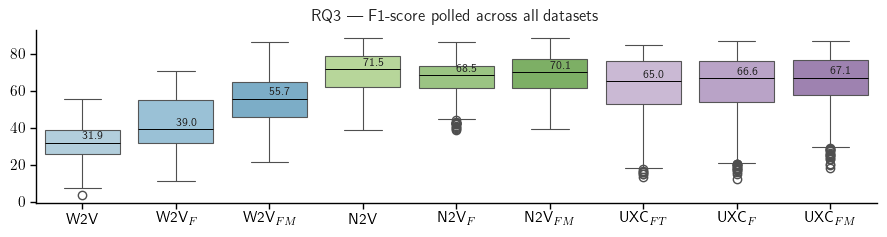

In [8]:
RQ3_subset = {k: RQ3[k] for k in ['W2V', 'W2V$_{F}$', 'W2V$_{FM}$', 'N2V', 'N2V$_{F}$', 'N2V$_{FM}$', 'UXC$_{FT}$', 'UXC$_{F}$', 'UXC$_{FM}$']}
boxplot_group(RQ3_subset, ['f1_micro'],
    'RQ3 — F1-score polled across all datasets',
    RESULTS_BASE / 'Figures' / 'RQ3_boxplot_f1_pooled.pdf')

In [278]:
rq3_stats  = stat_table(RQ3_subset,['f1_micro','f1_macro'])
rq3_stats.to_csv(RESULTS_BASE /'Statiscal_Test/rq3_stats.csv') 

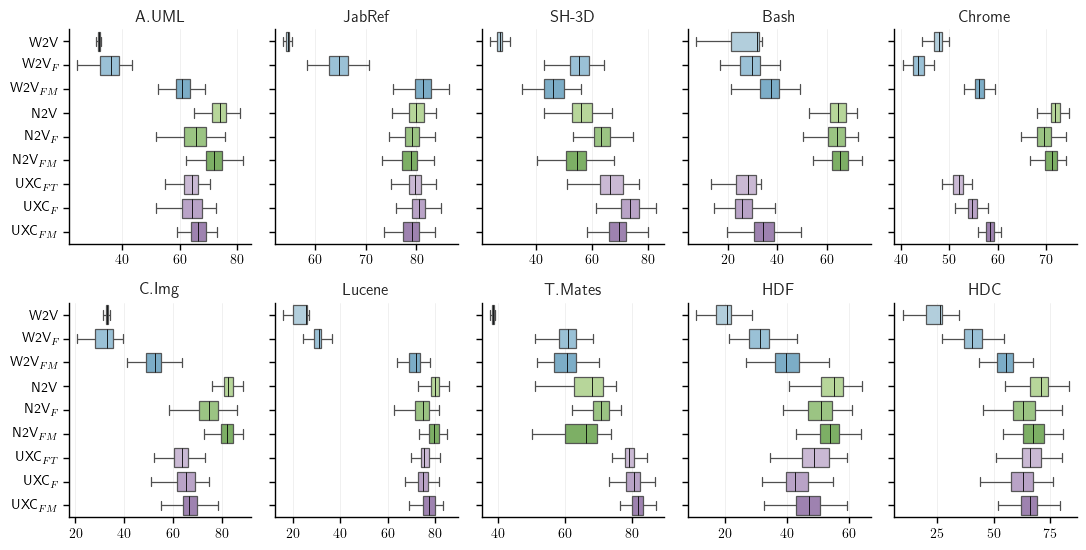

In [ ]:
boxplot_(RQ3_subset, 'f1_micro',title='', size=(11,5.8),
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_boxplot_f1_micro.pdf')

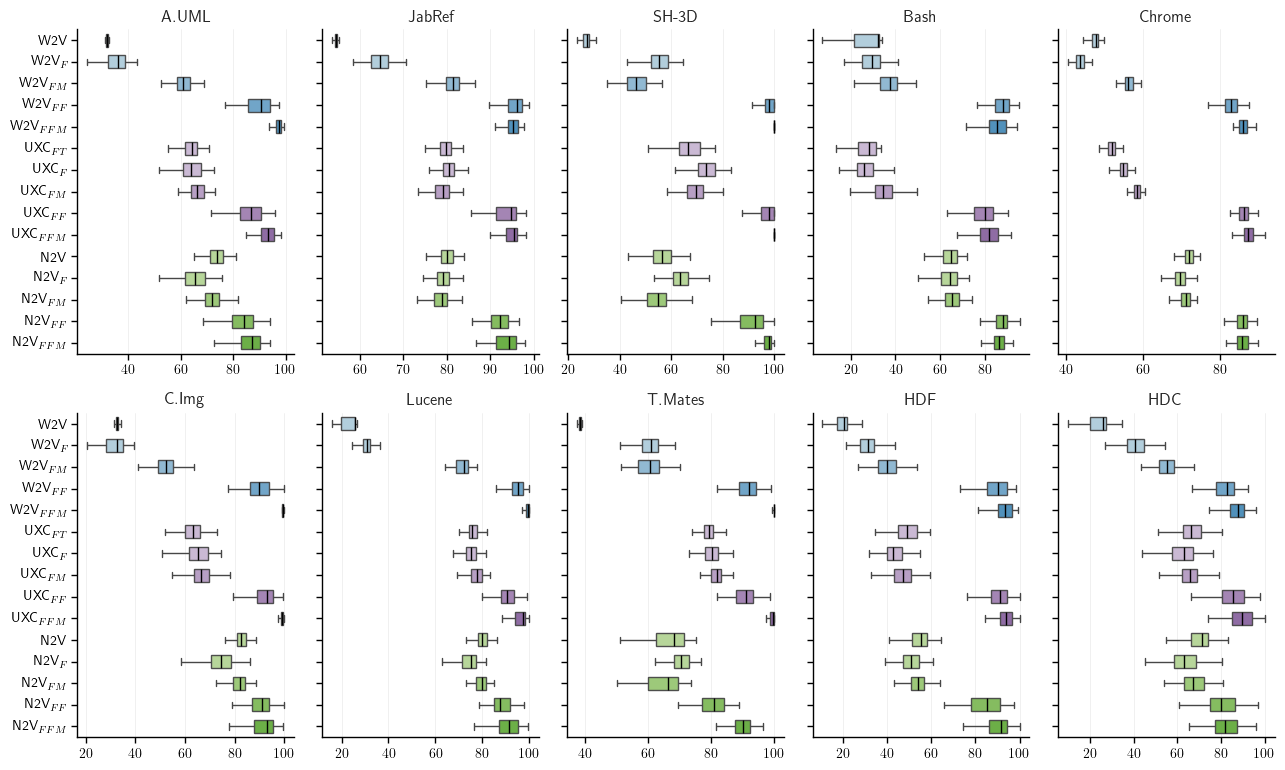

In [ ]:
boxplot_(RQ3, 'f1_micro',title='', size=(13,8),
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_boxplot_f1_micro_full.pdf')

In [116]:
rq2_stats  = stat_table(RQ3_subset,['f1_micro','f1_macro'])
rq2_stats.to_csv(RESULTS_BASE /'Statiscal_Test/rq3_stats.csv') 

In [ ]:
def lineplot_(data: dict, metric: str, condition_order: list, title: str,
                          size=(14, 6), nrows=2, ncols=5, save_path=None,
                          show_band=True, band_alpha=0.15,
                          annotate_median: bool = False, annotate_fontsize=8,
                          annotate_offset=4):
    """
    Grid of per-dataset line plots (median vs. increasing graph structure).
    One line per representation (method), one panel per dataset.
    Optionally shades the interquartile range (Q1-Q3) around each line.

    `data` is a dict: {representation_label: {condition_label: df}}
        e.g. data['W2V']['MLP'], data['W2V']['F'], data['W2V']['FM'], ...
    `condition_order` is the x-axis order, e.g. ['MLP', 'F', 'FM', 'FF', 'FFM'].
    `metric` is the column to plot the median of (e.g. 'f1_macro').
    `show_band` toggles the shaded IQR band; `band_alpha` controls its opacity.
    `annotate_median` toggles printing the rounded median value next to each
        point on the line (e.g. "72"). `annotate_fontsize` and
        `annotate_offset` (in points) control label size and placement.

    Datasets are laid out in DATASET_ORDER (via _ordered_datasets), column-major.
    """
    all_ds = _ordered_datasets(
        ds
        for rep_dict in data.values()
        for cond_df in rep_dict.values()
        for ds in cond_df['dataset'].unique()
    )
    if DATASETS:
        all_ds = [d for d in all_ds if d in DATASETS]

    labels = list(data.keys())  # representations: W2V, N2V, UXC-FT
    colors = method_colors(labels)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=size,
        sharey=False, sharex=True,
        squeeze=False
    )
    axes = axes.flatten(order='F')

    # Stagger annotation vertical offsets per representation so labels for
    # different lines at the same x-position don't overlap each other.
    n_reps = len(labels)
    offset_step = annotate_offset if n_reps <= 1 else annotate_offset * 1.2
    rep_offsets = {
        rep: annotate_offset + i * offset_step
        for i, rep in enumerate(labels)
    }

    for ax_i, ds in enumerate(all_ds):
        ax = axes[ax_i]

        for rep in labels:
            xs, meds, q1s, q3s = [], [], [], []
            for cond in condition_order:
                if cond not in data[rep]:
                    continue
                df = data[rep][cond]
                vals = df.loc[df['dataset'] == ds, metric].dropna().values * 100
                if len(vals) == 0:
                    continue
                xs.append(cond)
                meds.append(np.median(vals))
                q1s.append(np.percentile(vals, 25))
                q3s.append(np.percentile(vals, 75))

            if not xs:
                continue

            ax.plot(
                xs, meds,
                marker='o', markersize=4, linewidth=1.6,
                color=colors[rep], label=rep, zorder=3
            )

            if show_band:
                ax.fill_between(
                    xs, q1s, q3s,
                    color=colors[rep], alpha=band_alpha, linewidth=0, zorder=1
                )

            if annotate_median:
                for x, m in zip(xs, meds):
                    ax.annotate(
                        f'{m:.0f}',
                        xy=(x, m),
                        xytext=(0, rep_offsets[rep]),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=annotate_fontsize,
                        color=colors[rep],
                        zorder=4,
                    )

        ax.set_title(ds, fontsize=11)
        ax.set_ylabel('')
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelsize=9, rotation=0)
        ax.tick_params(axis='y', labelsize=9)
        ax.grid(axis='y', linewidth=0.4, alpha=0.4)

        if annotate_median:
            # Give annotated labels room at the top of each panel so they
            # don't get clipped against the axis border.
            ymin, ymax = ax.get_ylim()
            ax.set_ylim(ymin, ymax + 0.12 * (ymax - ymin))

    for ax_i in range(len(all_ds), len(axes)):
        axes[ax_i].set_visible(False)

    handles, labs = axes[0].get_legend_handles_labels()
    fig.legend(
    handles, labs,
    loc='upper center', bbox_to_anchor=(0.5, 1.03),
    ncol=len(labels), fontsize=12, frameon=False,
    handlelength=3,      # longer line swatch (default ~2)
    handleheight=1.5,    # taller swatch
    markerscale=1.5,     # bigger marker dot in the legend
    columnspacing=2.0,   # more space between legend entries
)

    fig.suptitle(title, fontsize=13, y=1.06)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
    plt.show()

In [ ]:

# ── usage for RQ3 ──────────────────────────────────────────────────────────
# RQ3 = load_group(RQ3_METHODS) returns a flat dict keyed by label string,
# e.g. RQ3['W2V'], RQ3['W2V$_{F}$'], RQ3['W2V$_{FM}$'], ... (see RQ3_METHODS).
# Re-group into {representation: {condition: df}} for the line plot.

RQ3_CONDITIONS = ['MLP', 'F', 'FM', 'FF', 'FFM']
def _rep_conditions(prefix, mlp_key=None):
    return {
        'MLP': RQ3[mlp_key if mlp_key else prefix],
        'F':   RQ3[f'{prefix}$_{{F}}$'],
        'FM':  RQ3[f'{prefix}$_{{FM}}$'],
        'FF':  RQ3[f'{prefix}$_{{FF}}$'],
        'FFM': RQ3[f'{prefix}$_{{FFM}}$'],
    }

RQ3_LINEPLOT_DATA = {
    'W2V':        _rep_conditions('W2V'),
    'N2V':        _rep_conditions('N2V'),
    'UXC$_{FT}$': _rep_conditions('UXC', mlp_key='UXC$_{FT}$'),
}

lineplot_(
    RQ3_LINEPLOT_DATA,
    metric='f1_micro',
    condition_order=RQ3_CONDITIONS,
    title='',
    band_alpha=0.3,
    annotate_median=False, annotate_fontsize=8, annotate_offset=4,
    size=(11, 5), nrows=2, ncols=5,
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_lineplot_f1_micro.pdf'
)

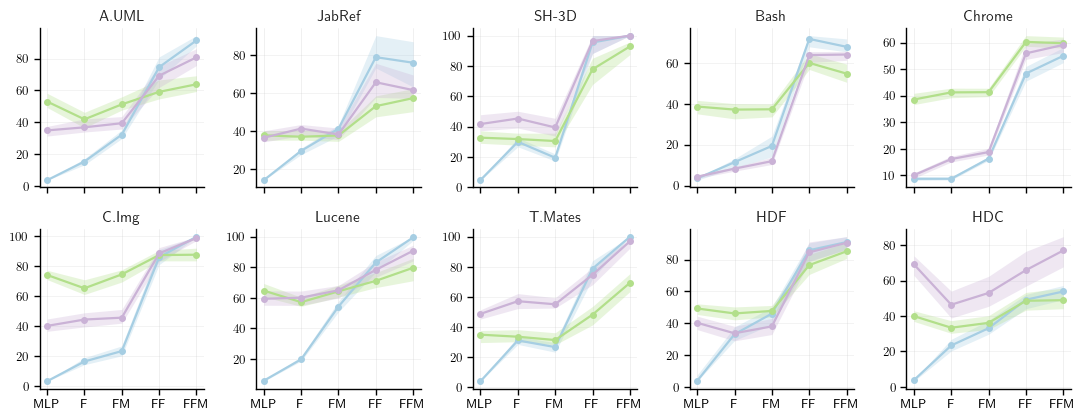

In [16]:
lineplot_(
    RQ3_LINEPLOT_DATA,
    metric='f1_macro',
    condition_order=RQ3_CONDITIONS,
    title='',
    band_alpha=0.3,
    size=(11, 4.5), nrows=2, ncols=5,
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_lineplot_f1_macro.pdf'
)

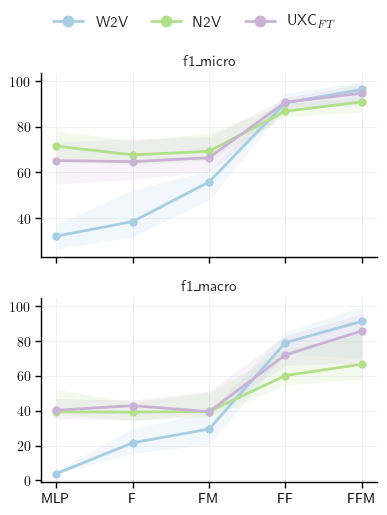

In [93]:
def aggregate_lineplot_(data: dict, metrics: list, condition_order: list, title: str,
                         size=(4, 8), save_path=None,
                         show_band=True, band_alpha=0.15):
    """
    One column of aggregated subplots, one row per metric.
    `metrics` is a list, e.g. ['f1_macro', 'f1_micro'].
    """
    labels = list(data.keys())
    colors = method_colors(labels)

    fig, axes = plt.subplots(len(metrics), 1, figsize=size, sharex=True, squeeze=False)
    axes = axes.flatten()

    for ax, metric in zip(axes, metrics):
        for rep in labels:
            xs, meds, q1s, q3s = [], [], [], []
            for cond in condition_order:
                if cond not in data[rep]:
                    continue
                df = data[rep][cond]
                per_sys = [
                    np.median(df.loc[df['dataset'] == ds, metric].dropna().values * 100)
                    for ds in df['dataset'].unique()
                    if df.loc[df['dataset'] == ds, metric].notna().any()
                ]
                if not per_sys:
                    continue
                per_sys = np.array(per_sys)
                xs.append(cond)
                meds.append(np.median(per_sys))
                q1s.append(np.percentile(per_sys, 25))
                q3s.append(np.percentile(per_sys, 75))

            if not xs:
                continue
            ax.plot(xs, meds, marker='o', markersize=5, linewidth=2,
                    color=colors[rep], label=rep, zorder=3)
            if show_band:
                ax.fill_between(xs, q1s, q3s, color=colors[rep], alpha=band_alpha,
                                 linewidth=0, zorder=1)

        ax.set_title(metric, fontsize=11)
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        ax.grid(axis='y', linewidth=0.4, alpha=0.4)

    handles, labs = axes[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc='upper center', bbox_to_anchor=(0.5, 1.04),
               ncol=len(labels), fontsize=11, frameon=False,
               markerscale=1.5, columnspacing=1.5)
    fig.suptitle(title, fontsize=13, y=1.08)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

aggregate_lineplot_(
    RQ3_LINEPLOT_DATA,
    metrics=['f1_micro', 'f1_macro'],
    condition_order=RQ3_CONDITIONS,
    title='',
    size=(4, 5),
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_lineplot_agg.pdf'
)

In [215]:
import math
import numpy as np
import matplotlib.pyplot as plt


def lineplot_macro_micro(
    data: dict,
    condition_order: list,
    title: str = '',
    size=(11, 10.5),
    ncols=5,
    save_path=None,
    show_band=True,
    band_alpha=0.30,
):
    """
    Plot macro-F1 and micro-F1 in two visibly separated sections.

    With 10 datasets and ncols=5:
        - Macro F1: 2 rows x 5 columns
        - Micro F1: 2 rows x 5 columns

    Each panel has independent y-axis limits and y-ticks.
    """

    metrics = ['f1_macro', 'f1_micro']

    metric_titles = {
        'f1_macro': 'Macro F1',
        'f1_micro': 'Micro F1',
    }

    all_ds = _ordered_datasets(
        ds
        for rep_dict in data.values()
        for cond_df in rep_dict.values()
        for ds in cond_df['dataset'].unique()
    )

    if DATASETS:
        all_ds = [ds for ds in all_ds if ds in DATASETS]

    labels = list(data.keys())
    colors = method_colors(labels)

    # With 10 datasets and 5 columns, this is 2 rows per metric.
    n_dataset_rows = math.ceil(len(all_ds) / ncols)

    # Constrained layout manages labels and titles automatically.
    fig = plt.figure(figsize=size, layout='constrained')

    outer = fig.add_gridspec(
        nrows=5,
        ncols=1,
        height_ratios=[
            0.08,  # Legend
            1.00,  # Macro F1 section
            0.03,  # Empty gap between sections
            0.03,  # Divider line
            1.00,  # Micro F1 section
        ],
    )

    legend_ax = fig.add_subplot(outer[0])
    legend_ax.axis('off')

    subfig_macro = fig.add_subfigure(outer[1])

    # outer[2] intentionally remains empty: it creates visual separation.

    # divider_ax = fig.add_subplot(outer[3])
    # divider_ax.axis('off')
    # divider_ax.axhline(
    #     y=0.5,
    #     xmin=0.02,
    #     xmax=0.98,
    #     color='0.55',
    #     linewidth=0.8,
    # )

    subfig_micro = fig.add_subfigure(outer[4])

    subfigures = {
        'f1_macro': subfig_macro,
        'f1_micro': subfig_micro,
    }

    all_axes = {}

    for metric in metrics:
        subfig = subfigures[metric]

        # Section title managed by the subfigure, not manually positioned.
        subfig.suptitle(
            metric_titles[metric],
            fontsize=14,
            fontweight='bold',
        )

        axes = subfig.subplots(
            nrows=n_dataset_rows,
            ncols=ncols,
            sharex=False,
            sharey=False,
            squeeze=False,
        )

        all_axes[metric] = axes

        for ds_i, ds in enumerate(all_ds):
            row = ds_i // ncols
            col = ds_i % ncols
            ax = axes[row, col]

            for rep in labels:
                xs, meds, q1s, q3s = [], [], [], []

                for cond in condition_order:
                    if cond not in data[rep]:
                        continue

                    df = data[rep][cond]

                    vals = (
                        df.loc[df['dataset'] == ds, metric]
                        .dropna()
                        .values * 100
                    )

                    if len(vals) == 0:
                        continue

                    xs.append(cond)
                    meds.append(np.median(vals))
                    q1s.append(np.percentile(vals, 25))
                    q3s.append(np.percentile(vals, 75))

                if not xs:
                    continue

                ax.plot(
                    xs,
                    meds,
                    marker='o',
                    markersize=4,
                    linewidth=1.6,
                    color=colors[rep],
                    label=rep,
                    zorder=3,
                )

                if show_band:
                    ax.fill_between(
                        xs,
                        q1s,
                        q3s,
                        color=colors[rep],
                        alpha=band_alpha,
                        linewidth=0,
                        zorder=1,
                    )

            # Every subplot corresponds to one dataset.
            ax.set_title(
                ds,
                fontsize=11,
                fontweight='bold',
                pad=5,
            )

            if row == n_dataset_rows - 1:
                ax.tick_params(axis='x', labelsize=10)
            else:
                ax.tick_params(axis='x', labelbottom=False)
            ax.tick_params(axis='y', labelsize=10)

            ax.grid(
                axis='y',
                linewidth=0.5,
                alpha=0.6,
            )

        # Hide unused grid cells, if the total number of datasets is
        # not exactly divisible by ncols.
        for empty_i in range(len(all_ds), n_dataset_rows * ncols):
            row = empty_i // ncols
            col = empty_i % ncols
            axes[row, col].set_visible(False)

    # Build one legend from the first macro-F1 subplot.
    handles, legend_labels = (
        all_axes['f1_macro'][0, 0].get_legend_handles_labels()
    )

    legend_ax.legend(
        handles,
        legend_labels,
        loc='center',
        ncol=len(labels),
        fontsize=12,
        frameon=False,
        handlelength=3,
        markerscale=1.5,
        columnspacing=2.0,
    )

    if title:
        fig.suptitle(
            title,
            fontsize=13,
            fontweight='bold',
        )

    if save_path:
        fig.savefig(
            save_path,
            bbox_inches='tight',
            dpi=300,
        )

    plt.show()

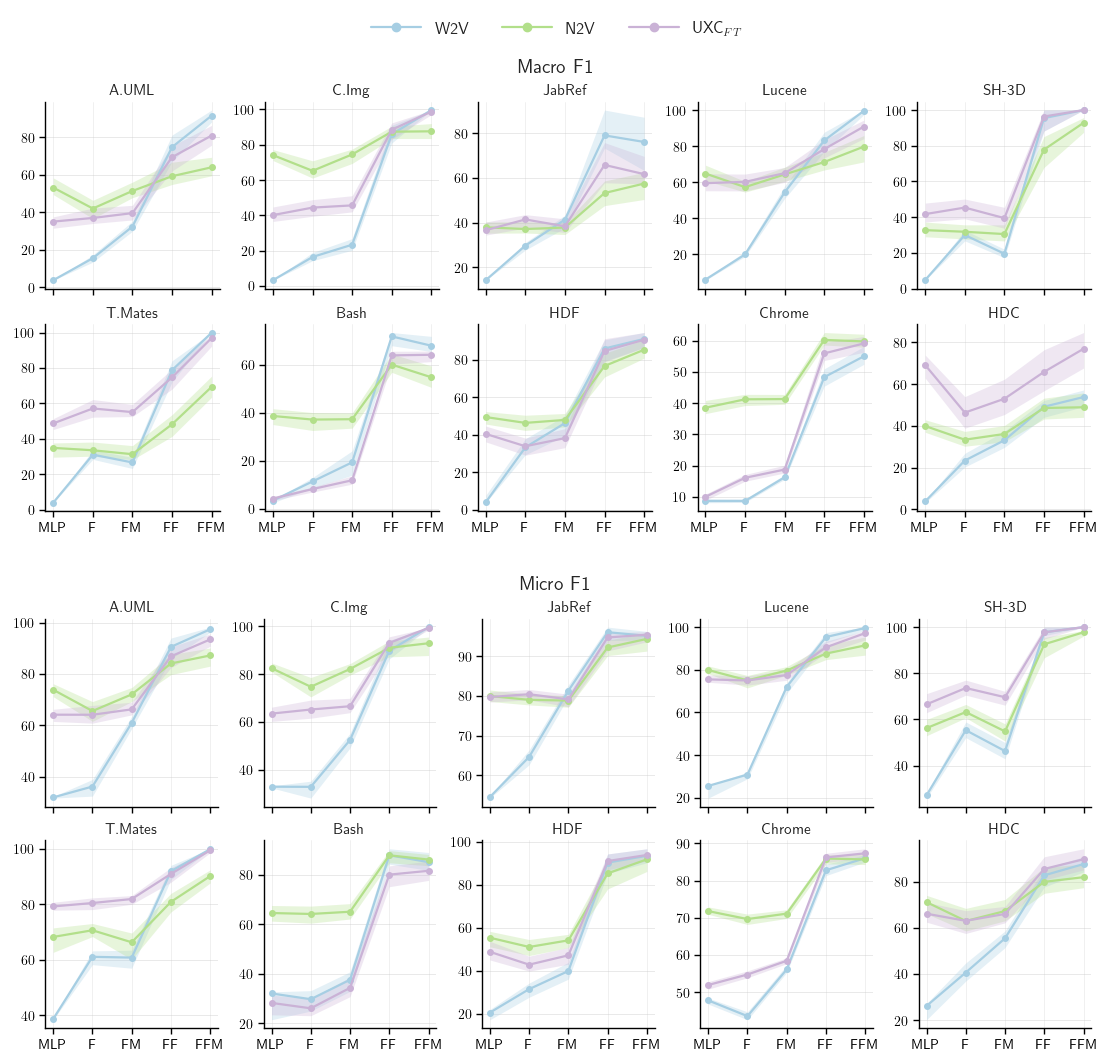

In [219]:
lineplot_macro_micro(
    RQ3_LINEPLOT_DATA,
    condition_order=RQ3_CONDITIONS,
    size=(11, 10.5),
    ncols=5,
    band_alpha=0.30,
    save_path=RESULTS_BASE / 'Figures' / 'RQ3_lineplot_f1_macro_micro.pdf',
)